# 01. Audio Exploration

This notebook introduces the ESC-50 dataset and explores five environmental sound classes:

- Dog
- Rain
- Crying baby
- Clock tick
- Helicopter

Run each cell from top to bottom.


In [14]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display


## 1. Locate the dataset

The notebook assumes that ESC-50 was cloned into:

`data/raw/ESC-50`


In [15]:
PROJECT_ROOT = Path.cwd().resolve()

# Jupyter normally starts from the repository root. This also handles
# starting it from inside the notebooks folder.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "ESC-50"
METADATA_PATH = DATASET_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = DATASET_ROOT / "audio"

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        "ESC-50 metadata was not found. Run:\n"
        "git clone https://github.com/karolpiczak/ESC-50.git data/raw/ESC-50"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")


Project root: C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier
Dataset root: C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier\data\raw\ESC-50


## 2. Read and inspect the metadata


In [16]:
metadata = pd.read_csv(METADATA_PATH)

print(f"Complete ESC-50 dataset shape: {metadata.shape}")
metadata.head()


Complete ESC-50 dataset shape: (2000, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## 3. Select the five project classes


In [17]:
SELECTED_CLASSES = [
    "dog",
    "rain",
    "crying_baby",
    "clock_tick",
    "helicopter",
]

selected_data = metadata[
    metadata["category"].isin(SELECTED_CLASSES)
].copy()

selected_data = selected_data.sort_values(
    ["category", "fold", "filename"]
).reset_index(drop=True)

print(f"Selected recordings: {len(selected_data)}")
print()
print(selected_data["category"].value_counts().sort_index())


Selected recordings: 200

category
clock_tick     40
crying_baby    40
dog            40
helicopter     40
rain           40
Name: count, dtype: int64


Each ESC-50 class contains 40 recordings. Therefore, five classes give us 200 recordings.


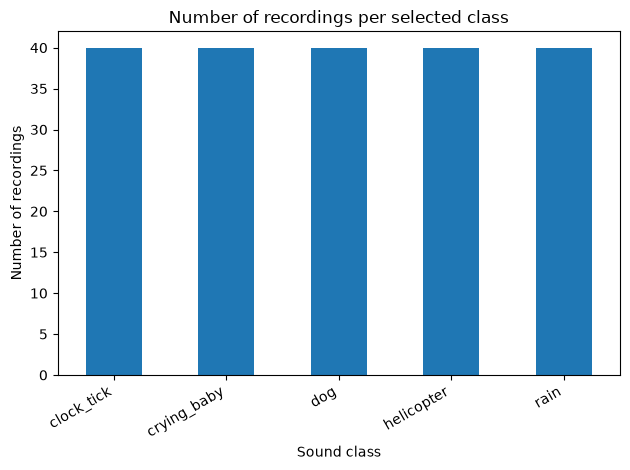

In [18]:
class_counts = (
    selected_data["category"]
    .value_counts()
    .sort_index()
)

ax = class_counts.plot(kind="bar")
ax.set_title("Number of recordings per selected class")
ax.set_xlabel("Sound class")
ax.set_ylabel("Number of recordings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4. Load and listen to one audio recording


In [19]:
sample_row = selected_data.iloc[0]
sample_path = AUDIO_DIR / sample_row["filename"]

audio_signal, sample_rate = librosa.load(sample_path, sr=None)

print(f"Class: {sample_row['category']}")
print(f"Filename: {sample_row['filename']}")
print(f"Fold: {sample_row['fold']}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {len(audio_signal) / sample_rate:.2f} seconds")

display(Audio(audio_signal, rate=sample_rate))


Class: clock_tick
Filename: 1-21934-A-38.wav
Fold: 1
Sample rate: 44100 Hz
Duration: 5.00 seconds


## 5. Plot the waveform


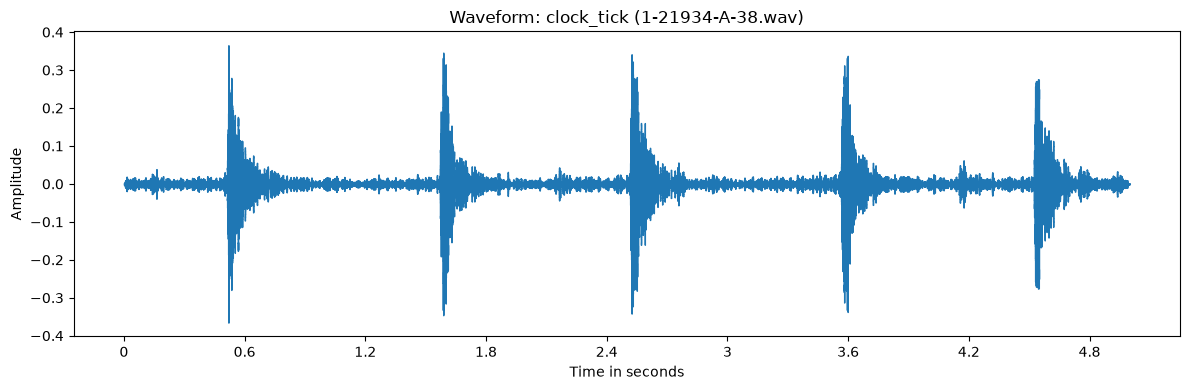

In [20]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio_signal, sr=sample_rate)
plt.title(
    f"Waveform: {sample_row['category']} "
    f"({sample_row['filename']})"
)
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


A waveform shows how the audio signal's amplitude changes over time.


## 6. Plot a Mel spectrogram


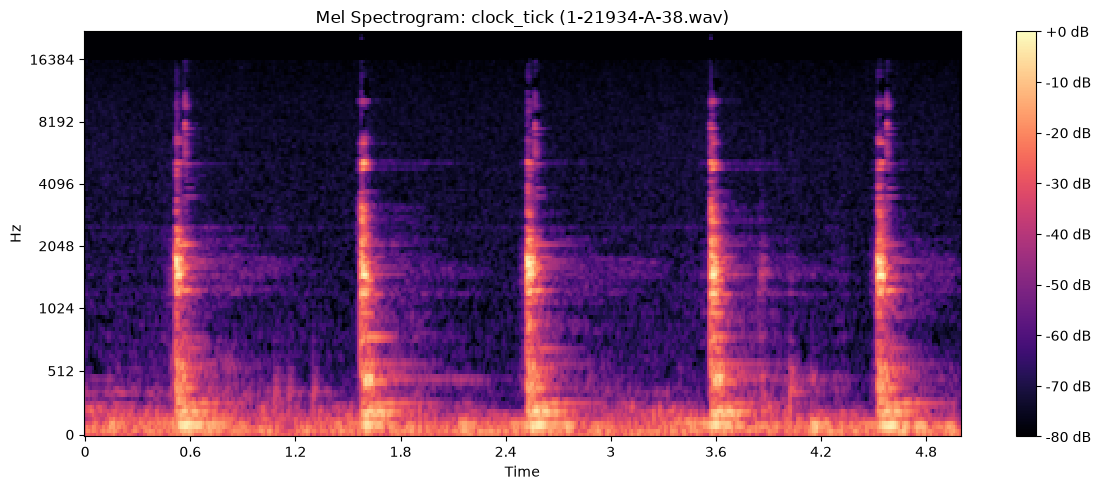

In [21]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=audio_signal,
    sr=sample_rate,
    n_mels=128,
)

mel_spectrogram_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max,
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mel_spectrogram_db,
    sr=sample_rate,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title(
    f"Mel Spectrogram: {sample_row['category']} "
    f"({sample_row['filename']})"
)
plt.tight_layout()
plt.show()


A Mel spectrogram shows how sound energy is distributed across frequencies and time. It is more useful for machine learning than the raw waveform because it exposes recognizable frequency patterns.


## 7. Listen to one recording from every selected class


In [23]:
for category in SELECTED_CLASSES:
    row = selected_data[
        selected_data["category"] == category
    ].iloc[0]

    file_path = AUDIO_DIR / row["filename"]
    signal, sr = librosa.load(file_path, sr=None)

    print(
        f"Class: {category} | "
        f"File: {row['filename']} | "
        f"Fold: {row['fold']}"
    )
    display(Audio(signal, rate=sr))


Class: dog | File: 1-100032-A-0.wav | Fold: 1


Class: rain | File: 1-17367-A-10.wav | Fold: 1


Class: crying_baby | File: 1-187207-A-20.wav | Fold: 1


Class: clock_tick | File: 1-21934-A-38.wav | Fold: 1


Class: helicopter | File: 1-172649-A-40.wav | Fold: 1


## First milestone complete

At this point, you should understand:

1. How ESC-50 stores its labels
2. How to load an audio file
3. What a waveform represents
4. What a Mel spectrogram represents
5. Which five classes will be used in the first model

The next notebook will extract MFCC and spectral features from all 200 recordings.
